# ToLD-Br — Alocação de Neyman + Estimadores Tipo Razão e Tipo Regressão

Este *notebook* executa o experimento central exigido pelo orientador:

1. **Amostragem estratificada sem reposição**, com SRS-WOR dentro de cada estrato;
2. **Alocação ótima de Neyman** ($n_h \propto N_h \sigma_h$, Cochran 1977 §5.5; Bolfarine & Bussab 2005 §5.5);
3. Estimação do parâmetro populacional $\bar{Y}$ por dois métodos com variável auxiliar — **estimador tipo razão** (Cochran §6.10–6.11) e **estimador tipo regressão** (Cochran §7.10–7.11);
4. **Comparação** entre as estimativas (separado vs. combinado, razão vs. regressão, Neyman vs. proporcional).

**Estimando**: $y = $ `total_severity` (soma das contagens de votos das 6 categorias, inteiro 0–18). É um índice de "preocupação total dos anotadores" sobre o tweet.

**Auxiliar**: $x = $ `word_count` (contagem de palavras), barata de calcular sobre toda a população e correlacionada com a intensidade de toxicidade.

Como o ToLD-Br é totalmente rotulado, conhecemos a verdade populacional $\bar{Y}$ e podemos medir o erro absoluto de cada estimador — algo impossível em uma aplicação real, mas didático em um trabalho metodológico.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

from toxicity_analysis.constants import TOLDBR_LABELS
from toxicity_analysis.estimators import compare_estimators
from toxicity_analysis.features import add_lexical_features
from toxicity_analysis.sampling import (
    calc_cochran,
    draw_stratified,
    neyman_allocation,
    proportional_allocation,
)

REPO_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
RAW_PATH = REPO_ROOT / "data" / "raw" / "told-br" / "train.csv"
OUT_DIR = REPO_ROOT / "data" / "processed"
FIG_DIR = OUT_DIR / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

LABELS = list(TOLDBR_LABELS)

## 1. Preparação: *features*, alvo e estratos

In [2]:
df = pd.read_csv(RAW_PATH)
df = add_lexical_features(df)
df["total_severity"] = df[LABELS].sum(axis=1)

PRIORIDADE = ["racism", "xenophobia", "misogyny", "homophobia", "insult", "obscene"]


def estrato_de(row: pd.Series) -> str:
    for label in PRIORIDADE:
        if row[label] >= 2:
            return label
    return "clean"


df["estrato"] = df.apply(estrato_de, axis=1)

verdade = float(df["total_severity"].mean())
correlacao = df[["word_count", "total_severity"]].corr().iloc[0, 1]
print(f"Verdade populacional Ȳ = {verdade:.4f}  (média de total_severity, N={len(df):,})")
print(f"Correlação x=word_count, y=total_severity: {correlacao:.3f}")

Verdade populacional Ȳ = 0.8591  (média de total_severity, N=21,000)
Correlação x=word_count, y=total_severity: 0.011


## 2. Tamanho amostral total via Cochran (1977)

Para honrar o orçamento clássico de $e=5\%$, $1-\alpha=95\%$, $p=0{,}5$:

In [3]:
headline = calc_cochran(N=len(df))
n_total = headline.n
print(f"Cochran: n0={headline.n0:.1f}, n={n_total} (z={headline.z:.3f})")

Cochran: n0=384.1, n=378 (z=1.960)


## 3. Alocação proporcional vs. ótima de Neyman

Comparamos as duas alocações que respeitam o orçamento $n=378$. Neyman privilegia estratos com maior variância interna de $y$, reduzindo $\mathrm{Var}(\hat{\bar{y}}_{st})$ para o mesmo $n$.

In [4]:
alloc_prop = proportional_allocation(df, "estrato", n=n_total)
alloc_neyman = neyman_allocation(df, "estrato", "total_severity", n=n_total)

alloc_table = pd.DataFrame({
    "N_h": df["estrato"].value_counts(),
    "sigma_h": df.groupby("estrato")["total_severity"].std(ddof=1).round(3),
    "proporcional": pd.Series(alloc_prop),
    "neyman": pd.Series(alloc_neyman),
}).reindex([*PRIORIDADE, "clean"])
alloc_table.loc["TOTAL"] = [
    alloc_table["N_h"].sum(),
    "",
    alloc_table["proporcional"].sum(),
    alloc_table["neyman"].sum(),
]
alloc_table

,N_h,sigma_h,proporcional,neyman
racism,33,1.955,1,2
xenophobia,42,2.434,1,3
misogyny,129,1.532,2,5
homophobia,172,1.567,3,7
insult,1755,1.129,31,55
obscene,1932,0.692,35,37
clean,16937,0.575,305,269
TOTAL,21000,,378,378


## 4. Sortear amostra de Neyman (semente fixa para reprodutibilidade)

In [5]:
amostra_neyman = draw_stratified(df, "estrato", alloc_neyman, random_state=42)
print(f"Amostra Neyman: n={len(amostra_neyman)}")
amostra_neyman["estrato"].value_counts().reindex([*PRIORIDADE, "clean"])

Amostra Neyman: n=378


estrato
racism          2
xenophobia      3
misogyny        5
homophobia      7
insult         55
obscene        37
clean         269
Name: count, dtype: int64

## 5. Estimação de $\bar{Y}$ por cinco métodos

1. **Média estratificada simples** ($\bar{y}_{st}$) — *baseline*.
2. **Razão separada** ($\hat{Y}_{Rs}$) — Cochran §6.10.
3. **Razão combinada** ($\hat{Y}_{Rc}$) — Cochran §6.11.
4. **Regressão separada** ($\hat{Y}_{lrs}$) — Cochran §7.10.
5. **Regressão combinada** ($\hat{Y}_{lrc}$) — Cochran §7.11.

Todos com variância grande-amostra com correção de população finita (FPC).

In [6]:
comparacao = compare_estimators(
    sample=amostra_neyman,
    population=df,
    stratum_col="estrato",
    x_col="word_count",
    y_col="total_severity",
).round(4)
comparacao.to_csv(OUT_DIR / "estimators_neyman_total_severity.csv")
comparacao

,point,se,ci_low,ci_high,abs_error
estimator,,,,,
stratified_mean,0.8676,0.0345,0.7999,0.9353,0.0085
ratio_separate,0.9203,0.0563,0.8099,1.0306,0.0611
ratio_combined,0.8532,0.0489,0.7574,0.9490,0.0059
regression_separate,0.8787,0.0342,0.8116,0.9458,0.0196
regression_combined,0.8672,0.0345,0.7996,0.9348,0.0080
population_mean,0.8591,NaN,NaN,NaN,0.0000


**Cobertura do IC de 95% sobre a verdade populacional:**

In [7]:
cobertura = comparacao.copy()
cobertura["verdade"] = verdade
cobertura["cobre_verdade"] = (cobertura["ci_low"] <= verdade) & (verdade <= cobertura["ci_high"])
cobertura[["point", "se", "ci_low", "ci_high", "verdade", "cobre_verdade", "abs_error"]]

,point,se,ci_low,ci_high,verdade,cobre_verdade,abs_error
estimator,,,,,,,
stratified_mean,0.8676,0.0345,0.7999,0.9353,0.859143,True,0.0085
ratio_separate,0.9203,0.0563,0.8099,1.0306,0.859143,True,0.0611
ratio_combined,0.8532,0.0489,0.7574,0.9490,0.859143,True,0.0059
regression_separate,0.8787,0.0342,0.8116,0.9458,0.859143,True,0.0196
regression_combined,0.8672,0.0345,0.7996,0.9348,0.859143,True,0.0080
population_mean,0.8591,NaN,NaN,NaN,0.859143,False,0.0000


## 6. Visualização — IC de 95% por estimador

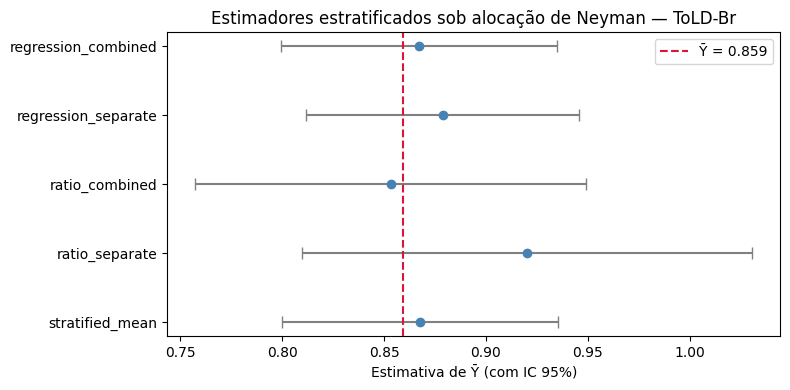

In [8]:
comp_plot = comparacao.drop("population_mean")
fig, ax = plt.subplots(figsize=(8, 4))
y_pos = range(len(comp_plot))
ax.errorbar(
    comp_plot["point"],
    list(y_pos),
    xerr=[comp_plot["point"] - comp_plot["ci_low"], comp_plot["ci_high"] - comp_plot["point"]],
    fmt="o",
    color="steelblue",
    ecolor="gray",
    capsize=4,
)
ax.axvline(verdade, color="crimson", linestyle="--", label=f"Ȳ = {verdade:.3f}")
ax.set_yticks(list(y_pos))
ax.set_yticklabels(comp_plot.index)
ax.set_xlabel("Estimativa de Ȳ (com IC 95%)")
ax.set_title("Estimadores estratificados sob alocação de Neyman — ToLD-Br")
ax.legend()
fig.tight_layout()
fig.savefig(FIG_DIR / "estimators_comparison_neyman.png", dpi=150)
plt.show()

## 7. Repetição com a alocação proporcional (controle)

Para confirmar que Neyman reduz a variância em relação à alocação proporcional para o mesmo $n$, repetimos a estimação com a amostra proporcional.

In [9]:
amostra_prop = draw_stratified(df, "estrato", alloc_prop, random_state=42)
comparacao_prop = compare_estimators(
    sample=amostra_prop,
    population=df,
    stratum_col="estrato",
    x_col="word_count",
    y_col="total_severity",
).round(4)
comparacao_prop

,point,se,ci_low,ci_high,abs_error
estimator,,,,,
stratified_mean,0.8707,0.0377,0.7969,0.9445,0.0115
ratio_separate,0.9346,0.0704,0.7966,1.0726,0.0755
ratio_combined,0.8682,0.0500,0.7702,0.9661,0.0090
regression_separate,0.8713,0.0369,0.7990,0.9436,0.0122
regression_combined,0.8705,0.0376,0.7968,0.9442,0.0114
population_mean,0.8591,NaN,NaN,NaN,0.0000


In [10]:
se_compare = pd.DataFrame({
    "se_proporcional": comparacao_prop["se"],
    "se_neyman": comparacao["se"],
})
se_compare["reducao_pct"] = (
    (se_compare["se_proporcional"] - se_compare["se_neyman"])
    / se_compare["se_proporcional"]
    * 100
).round(2)
se_compare = se_compare.drop("population_mean")
se_compare.to_csv(OUT_DIR / "se_comparison_prop_vs_neyman.csv")
se_compare

,se_proporcional,se_neyman,reducao_pct
estimator,,,
stratified_mean,0.0377,0.0345,8.49
ratio_separate,0.0704,0.0563,20.03
ratio_combined,0.0500,0.0489,2.20
regression_separate,0.0369,0.0342,7.32
regression_combined,0.0376,0.0345,8.24


## Saídas geradas

- `data/processed/estimators_neyman_total_severity.csv` — tabela dos cinco estimadores sob Neyman + verdade populacional.
- `data/processed/se_comparison_prop_vs_neyman.csv` — comparação de erros-padrão entre alocações.
- `data/processed/figures/estimators_comparison_neyman.png` — figura *forest plot* dos IC95% para a §5 do artigo.

## Leitura para o artigo

- **Q1.** Qual estimador apresenta o menor erro absoluto contra a verdade $\bar{Y}$?
- **Q2.** Em quanto Neyman reduz o erro-padrão em relação à alocação proporcional, para o mesmo $n=378$?
- **Q3.** A vantagem da regressão sobre a razão se manifesta apenas se $x$ e $y$ forem aproximadamente lineares com intercepto não-nulo (Cochran §7.1) — observamos isso nos dados?